In [1]:
import warnings
from typing import List, Literal, Optional, Tuple

import moscot as mt
import moscot.plotting as mtp
import ot
import tqdm
from moscot.problems.time import LineageProblem, TemporalProblem

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import euclidean_distances

import matplotlib.pyplot as plt
import pycea as py

import scanpy as sc
from anndata import AnnData
import treedata as td

warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", FutureWarning)

In [2]:
pwd

'/project/imoskowitz/yubin'

In [3]:
cd Lineage_Tree_Construction/

/project/imoskowitz/yubin/Lineage_Tree_Construction


In [4]:
from Moslin.utility import compute_w2, get_cost, compute_errors

Early run, only first replicate is used. Since there are also multiple clones in the replicate, I will take the clone with the biggest lineage tree and as a result should probably subset the data before we concat. 
TODO: Figure out why there are multiple clones. Why the nodes in the tree and the clone cell count do not match up 
TODO: Create cost matrix for each time point, and the cost matrix 
TODO: Use Gene Expression for cost matrix across time points 

#### Data loading and Subsetting

In [5]:
from pathlib import Path
basePath = "/project/imoskowitz/yubin/Lineage_Tree_Construction/"
output_data = basePath + "output_data/"
output_plot = basePath + "output_plot/"

In [6]:
Lineage_data = Path("/project/imoskowitz/kdreyer/public_datasets/005_Colgan2026/")
tdatas = {}
for file_path in Lineage_data.glob("*R1.h5td"): # Loading one day at a time because otherwise the file size will be overloaded
    tdatas[file_path.stem] = td.read_h5td(file_path)

In [7]:
adata = tdatas["E7.5-R1"][tdatas["E7.5-R1"].obs["tree"]=="E7.5-R1-C1"]

### Sanity check to see if subsetting will affect the lineage tree in any way (Compared with the tree generated in tree_explore.ipynb)

In [8]:
py.pp.add_depth(adata)

<PolarAxes: >

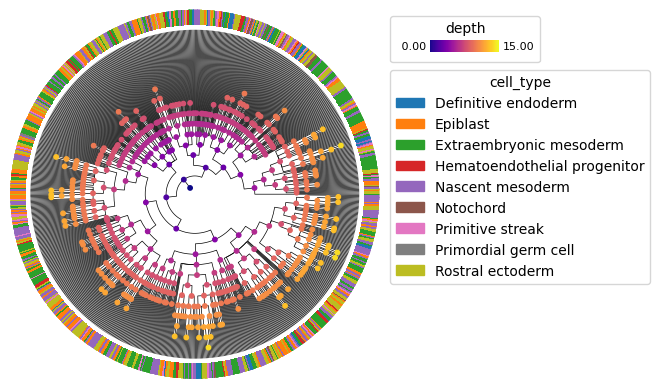

In [9]:
py.pl.branches(adata, polar=True, extend_branches=True, tree="E7.5-R1-C1")
py.pl.nodes(adata, color='depth', cmap="plasma")
py.pl.annotation(adata, keys='cell_type', cmap='viridis', width=.1)